# IMPORT

In [1]:
# Thư viện chuẩn của Python
import os
import re
import time
import random
import json
# Xử lý dữ liệu
import pandas as pd
import numpy as np
np.bool = np.bool_  # Khắc phục cảnh báo với kiểu np.bool
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Thống kê & phân tích chuỗi thời gian
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
# Đánh giá mô hình
from sklearn.metrics import mean_squared_error, mean_absolute_error
# TensorFlow / Keras – xây dựng mô hình deep learning
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import *

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns
# Tiện ích hỗ trợ
from tqdm import tqdm

# DEF

## DEF_DATA

In [2]:
# Kiểm tra thông tin tập dữ liệu
def check_information_dataset (dataset):
    # Thông tin kích thước tập dữ liệu
    print (dataset.shape)
    # Thông tin tổng quan về các trường dữ liệu
    print(dataset.info())
    # Thống kê mô tả (mean, std, min, max) của các trường số
    print(dataset.describe())

# TIền xử lý dữ liệu
def preprocess_data(dataset, drop_threshold=1):
    # Chuyển đổi trường Date sang kiểu dữ liệu datetime để có thể sử dụng trong các phép toán thời gian.
    dataset['date'] = pd.to_datetime(dataset['date'], format='%d/%m/%Y') 
    # Đặt cột Date làm chỉ mục
    dataset.set_index('date', inplace=True)
    # Chuyển đổi dữ liệu thành dạng số, các giá trị không thể chuyển thành số sẽ bị thay bằng NaN
    for col in dataset.columns:
        if dataset[col].dtype == object: # correct type
            dataset[col] = pd.to_numeric(dataset[col].str.replace(',', '.'))
    dataset = dataset.apply(pd.to_numeric, errors='coerce')
    # Loại bỏ các cột có quá nhiều giá trị khuyết thiếu
    missing_ratios = dataset.isnull().mean()  # Tính tỷ lệ thiếu dữ liệu trên mỗi cột
    columns_to_drop = missing_ratios[missing_ratios > drop_threshold].index # Xác định các cột có tỷ lệ thiếu > 1
    dataset.drop(columns=columns_to_drop, inplace=True) # Loại bỏ các cột đó
    # Nội suy tuyến tính dựa trên khoảng cách thời gian
    dataset.interpolate(method='time', inplace=True)
    # Điền nốt giá trị còn thiếu nếu có
    dataset.fillna(dataset.mean(), inplace=True)  
    # Loại bỏ các hàng có chỉ mục NaN
    dataset = dataset[~dataset.index.isnull()]
    # Loại bỏ các dòng trùng lặp
    dataset.drop_duplicates(inplace=True)
    return dataset

# Phát sinh dữ liệu
# Thêm nhiễu Gaussian (phân phối chuẩn) vào một chuỗi thời gian.
def add_gaussian_noise(time_series, mean, stddev):
    noise = np.random.normal(mean, stddev, len(time_series))  # Tạo nhiễu Gaussian
    noisy_series = time_series + noise  # Thêm nhiễu vào dữ liệu gốc
    return noisy_series


# Sinh tập chỉ mục thời gian mới với số lượng periods bằng số lượng dòng của dữ liệu gốc
def generate_new_dates(df, periods):
    first_date = df.index.min()  # Lấy ngày nhỏ nhất trong dữ liệu gốc
    return pd.date_range(end=first_date - pd.DateOffset(days=1),
                         periods=periods,
                         freq='D')  # Sinh danh sách ngày mới, cách nhau 1 ngày


# Tạo một bản sao dữ liệu gốc có nhiễu Gaussian và ghép vào dữ liệu ban đầu
# stddev = 0.1 * data.std()  # Chọn 10% độ lệch chuẩn của dữ liệu gốc
# mean=0.0
def augment_with_gaussian(data, mean, stddev): 
    augmented_datasets = []
    augmented_data = data.copy()
        
    for column in data.columns:
        if np.issubdtype(data[column].dtype, np.number):  # Kiểm tra cột có phải là số không
            augmented_data[column] = add_gaussian_noise(
                data[column].dropna(), mean, stddev)
        
    new_dates = generate_new_dates(data, len(data))  # Sinh index mới
    augmented_data.index = new_dates  # Gán index mới cho dữ liệu có nhiễu
    augmented_datasets.append(augmented_data)
        
    return pd.concat([data] + augmented_datasets, axis=0).sort_index()  # Hợp nhất và sắp xếp index


# Phát sinh dữ liệu mới bằng phương pháp Numpy dựa trên xu hướng (trend), mùa vụ (seasonality) và nhiễu Gaussian (noise)
def augment_timeseries_data(data, n_periods):    
    new_dates = generate_new_dates(data, n_periods)
    augmented_data = []
    
    for column in data.columns:
        # Tính toán thống kê của dữ liệu gốc
        mean = data[column].mean()
        std = data[column].std()
        trend = np.polyfit(range(len(data)), data[column].values, 1)[0]
        
        # Tạo thành phần xu hướng
        base_trend = -np.arange(n_periods)[::-1] * trend + mean
        # Tạo thành phần mùa vụ
        seasonality = np.sin(np.linspace(0, 2*np.pi, 12)) * std * 0.5
        # Thêm nhiễu Gaussian
        noise = np.random.normal(0, std * 0.1, n_periods)
        
        # Tạo chuỗi thời gian mới
        # Chuỗi mới có xu hướng, mùa vụ và nhiễu giống dữ liệu gốc
        new_series = pd.Series(
            base_trend + np.tile(seasonality, n_periods//12 + 1)[:n_periods] + noise,
            index=new_dates
        )
        # Ghép dữ liệu mới vào dữ liệu gốc & sắp xếp lại theo thời gian.
        augmented_data.append(new_series)
    
    return (pd.concat([pd.DataFrame(dict(zip(data.columns, augmented_data))), data])).sort_index()

# Kiểm tra tính dừng
def adf_test(series, title=''):
    series_clean = series.dropna()
    result = adfuller(series_clean)
    
    return {
        'Column': title,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

# In kết quả kiểm tra tính dừng
def check_stationarity(data):
    results = []
    
    for column in data.columns:
        result = adf_test(data[column], title=column)
        results.append(result)

    return pd.DataFrame(results)

# Lấy sai phân bậc 1
def difference_series(series, lag=1):
    return series.diff(periods=lag).dropna()

# Dừng hoá dữ liệu bằng cách lấy sai phân bậc 1
def make_stationary(data, lag=1):
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Input data must be a pandas DataFrame.")
    
    non_numeric_columns = data.select_dtypes(exclude=['number']).columns
    if not non_numeric_columns.empty:
        print(f"Warning: Non-numeric columns excluded: {list(non_numeric_columns)}")

    numeric_data = data.select_dtypes(include=['number'])
    differenced_data = numeric_data.apply(difference_series, lag=lag)

    return differenced_data

# Chuẩn hoá dữ liệu bằng min-max    
def min_max_normalize (min,max,dataset):
    scaler = MinMaxScaler(feature_range=(min, max))
    scaled_data = pd.DataFrame(
                scaler.fit_transform(dataset),
                columns=dataset.columns,
                index=dataset.index,
            )
    return scaled_data, scaler

# Chuẩn hoá dữ liệu bằng z-score
def z_score_normalize (dataset):
    scaler = StandardScaler()
    scaled_data = pd.DataFrame(
                scaler.fit_transform(dataset),
                columns=dataset.columns,
                index=dataset.index,
            )
    return scaled_data, scaler



## DEF_VISUALIZATION

In [3]:
# So sánh dữ liệu tăng cường và dữ liệu gốc
def compare_original_augmented(dataset, dataset_aug, column, figsize=(10, 8)):
    if column not in dataset.columns or column not in dataset_aug.columns:
        raise ValueError(f"Cột '{column}' không tồn tại trong một trong hai DataFrame.")
    plt.figure(figsize=figsize)

    # Biểu đồ 1: So sánh toàn bộ dữ liệu
    plt.subplot(2, 1, 1)
    plt.plot(dataset[column], label="Original", alpha=0.7)
    plt.plot(dataset_aug[column], label="Augmented", alpha=0.5, linestyle='--')
    plt.legend()
    plt.title(f"So sánh dữ liệu gốc và dữ liệu tăng cường - {column}")

    # Biểu đồ 2: Chỉ phần dữ liệu mới (trước thời gian của dataset gốc)
    plt.subplot(2, 1, 2)
    augmented_part = dataset_aug.loc[dataset_aug.index < dataset.index.min()]
    plt.plot(augmented_part.index, augmented_part[column], label="Generated Data", linestyle='--', color='red')
    plt.legend()
    plt.title(f"Chỉ phần dữ liệu tăng cường - {column}")

    plt.tight_layout()
    plt.show()

# Vẽ biểu đồ phân phối giá trị các trường
def plot_distribution(data, column, bins=30, figsize=(10,6)):
    if column not in data.columns:
        raise ValueError(f"Cột '{column}' không tồn tại trong DataFrame.")

    plt.figure(figsize=figsize)
    sns.histplot(data[column], bins=bins, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# Vẽ biểu đồ đường quan sát sự thay đổi theo thời gian
def plot_smoothed_time_series(dataset, column, window=7, title=None, xlabel="Date", ylabel=None, figsize=(10, 5)):
    if column not in dataset.columns:
        raise ValueError(f"Cột '{column}' không tồn tại trong DataFrame.")
    
    smoothed = dataset[column].rolling(window=window, center=True).mean()
    
    plt.figure(figsize=figsize)
    plt.plot(dataset.index, smoothed, label=f'{window}-day Rolling Mean', color='orange')
    plt.plot(dataset.index, dataset[column], label='Original', alpha=0.3)  # gốc mờ
    plt.title(title if title else f"Smoothed Change in {column} through date")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel else column)
    plt.legend()
    plt.show()

# Trực quan hoá tập train-validation-test
def plot_dataset_split(name):
    plt.figure(figsize=(16, 4))

    plt.plot(train.index, train[name], label='Train', color='blue')
    plt.plot(val.index, val[name], label='Validation', color='orange')
    plt.plot(test.index, test[name], label='Test', color='green')

    plt.title(f'Data Split - {name}')
    plt.xlabel('Time')
    plt.ylabel(name)
    plt.legend()
    plt.grid(True)
    plt.show()

# Vẽ biểu đồ loss
def plot_loss_curve(loss_df):
    plt.figure(figsize=(10, 5))
    plt.plot(loss_df["Epoch"], loss_df["Training Loss"], label="Training Loss")
    plt.plot(loss_df["Epoch"], loss_df["Validation Loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_actual_vs_predicted(y_test, predictions, variable_index=0, step_index=0, variable_name=None):
    """
    Vẽ biểu đồ so sánh giữa giá trị thực tế và dự báo cho một biến cụ thể ở bước look-ahead xác định.

    Parameters:
    -----------
    y_test : ndarray
        Dữ liệu thực tế có shape (samples, time steps, variables)
    predictions : ndarray
        Dữ liệu dự báo có shape giống y_test
    variable_index : int
        Chỉ số biến cần so sánh (trục thứ 2 của mảng)
    step_index : int
        Bước look-ahead (trục thứ 1 của mảng)
    variable_name : str, optional
        Tên biến để hiển thị trên biểu đồ (nếu có)
    """
    plt.figure(figsize=(12, 5))
    plt.plot(y_test[:, step_index, variable_index], label='Actual')
    plt.plot(predictions[:, step_index, variable_index], label='Predicted')
    
    var_label = variable_name if variable_name else f"Variable {variable_index}"
    plt.title(f"Actual vs Predicted - {var_label} (Look-ahead step {step_index + 1})")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## DEF_MODELING

In [4]:
# Tìm lag tốt nhất
def find_bestlag (train_data, range_lag):
    
    results = []
    AIC = {}
    best_aic, best_lag = np.inf, 0
    
    for i in tqdm(range(range_lag)):
        model = VAR(endog = train_data.values)
        model_result = model.fit(maxlags=i)
        AIC[i] = model_result.aic
            
        results.append([i, AIC[i]])
        if AIC[i] < best_aic:
            best_aic = AIC[i]
            best_lag = i
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['p', 'AIC']
    result_df = result_df.sort_values(by='p', ascending=True).reset_index(drop=True)

    plt.figure(figsize=(14,5))
    plt.plot(range(len(AIC)), list(AIC.values()))
    plt.plot([best_lag], [best_aic], marker='o', markersize=8, color="red")
    ticks = list(range(0, len(AIC), 1))
    labels = [str(i) for i in ticks]
    plt.xticks(ticks, labels, rotation=90)
    plt.xlabel('lags'); plt.ylabel('AIC')
    print (result_df)
    return best_lag

# Tạo dự đoán từ mô hình VAR
def create_var_predictions(data, model, lag_order, features):
    lagged_data = []
    for i in range(lag_order, len(data)):        
        pred = model.forecast(data[features].values[i-lag_order:i], steps=1)
        lagged_data.append(pred[0])
    
    return np.array(lagged_data)

# Tạo cửa sổ trượt
def create_windows(data, window_shape, step=1, start_id=None, end_id=None):
    data = np.asarray(data)
    data = data.reshape(-1, 1) if np.prod(data.shape) == np.max(data.shape) else data

    start_id = 0 if start_id is None else start_id
    end_id = data.shape[0] if end_id is None else end_id

    data = data[int(start_id):int(end_id), :]
    window_shape = (int(window_shape), data.shape[-1])
    step = (int(step),) * data.ndim
    slices = tuple(slice(None, None, st) for st in step)
    indexing_strides = data[slices].strides
    win_indices_shape = ((np.array(data.shape) - window_shape) // step) + 1

    new_shape = tuple(list(win_indices_shape) + list(window_shape))
    strides = tuple(list(indexing_strides) + list(data.strides))

    window_data = np.lib.stride_tricks.as_strided(data, shape=new_shape, strides=strides)
    
    return np.squeeze(window_data, 1)

# Gieo số ngẫu nhiên
def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)

# Xây dựng mô hình deepvar (var_lstm)
def build_deepvar(input_dim, output_dim, look_back, look_ahead, lr, units_lstm):
    """
    input_dim: số đặc trưng (n_features)
    output_dim: số đầu ra tại mỗi bước (n_outputs)
        - 'lr': learning rate
        - 'units_lstm': số units của LSTM
        - 'look_back': số bước nhìn lại (sequence length đầu vào)
        - 'look_ahead': số bước dự đoán (sequence length đầu ra)
    """
    set_seed(33)

    input_shape = (look_back, input_dim)
    inp = Input(shape=input_shape)

    x = LSTM(units_lstm, activation='tanh')(inp)
    x = RepeatVector(look_ahead)(x)
    x = LSTM(units_lstm, activation='tanh', return_sequences=True)(x)
    out = TimeDistributed(Dense(output_dim))(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])

    return model

# Tìm tham số tối ưu
def grid_search(train_var_pred, train_targets, val_var_pred, val_targets, param_grid, look_backk, look_aheadd):
    best_param = None
    best_mse = float("inf")
    start_time = time.time()

    if train_var_pred.shape[0] != train_targets.shape[0]:
        raise ValueError("Mismatch between training features and targets dimensions.")
    if val_var_pred.shape[0] != val_targets.shape[0]:
        raise ValueError("Mismatch between validation features and targets dimensions.")
    
    if not all(key in param_grid for key in ['learning_rate', 'batch_size', 'units_lstm', 'epoch']):
        raise ValueError("Parameter grid must contain 'learning_rate', 'batch_size', 'units_lstm', and 'epoch'.")
    es = tf.keras.callbacks.EarlyStopping(patience=30, verbose=0, min_delta=0.001, monitor='val_loss', mode='auto', restore_best_weights=True)

    for lr in param_grid['learning_rate']:
        for batch_size in param_grid['batch_size']:
            for units_lstm in param_grid['units_lstm']:
                for epoch in param_grid['epoch']:
                    model = build_deepvar(input_dim=train_var_pred.shape[2], 
                                        output_dim=train_targets.shape[2], 
                                        look_back = look_backk ,
                                        look_ahead = look_aheadd,
                                        lr=lr,
                                        units_lstm=units_lstm)
                    model.fit(
                        train_var_pred, train_targets,
                        epochs=epoch,
                        batch_size=batch_size,
                        validation_data=(val_var_pred, val_targets),
                        verbose=0,
                        callbacks=[es]
                    )

                    val_var_lstm_pred = model.predict(val_var_pred)
                    # Để tính MSE trên toàn bộ dữ liệu cần flatten (làm phẳng) toàn bộ mảng
                    mse = mean_squared_error(val_targets.flatten(), val_var_lstm_pred.flatten())
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {
                            'learning_rate': lr,
                            'batch_size': batch_size,
                            'units_lstm': units_lstm,
                            'epoch': epoch
                        }

    execution_time = time.time() - start_time

    return best_params, best_mse, execution_time

# Kết quả đánh giá cho từng biến
def evaluate_multivariate_forecast(y_test, predictions, column_names):
    mse_dict = {}
    rmse_dict = {}
    mae_dict = {}
    cv_rmse_dict = {}

    for i, col in enumerate(column_names):
        mse = mean_squared_error(y_test[..., i], predictions[..., i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test[..., i], predictions[..., i])
        y_mean = np.mean(y_test[..., i])
        cv_rmse = rmse / y_mean if y_mean != 0 else np.nan

        mse_dict[col] = mse
        rmse_dict[col] = rmse
        mae_dict[col] = mae
        cv_rmse_dict[col] = cv_rmse

    evaluation_df = pd.DataFrame({
        'Variable': column_names,
        'MSE': pd.Series(mse_dict),
        'RMSE': pd.Series(rmse_dict),
        'MAE': pd.Series(mae_dict),
        'CV_RMSE': pd.Series(cv_rmse_dict)
    })

    return evaluation_df

def evaluate_overall_forecast(y_test, predictions, execution_time=None):
    test_mse = mean_squared_error(y_test.flatten(), predictions.flatten())
    test_mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
    test_rmse = np.sqrt(test_mse)
    y_mean = np.mean(y_test.flatten())
    cv_rmse = test_rmse / y_mean if y_mean != 0 else np.nan

    metric_names = [
        "Test Time (seconds)",
        "Test MSE",
        "Test MAE",
        "Test RMSE",
        "Test CV RMSE"
    ]
    metric_values = [
        f"{execution_time:.2f}" if execution_time is not None else "N/A",
        f"{test_mse:.4f}",
        f"{test_mae:.4f}",
        f"{test_rmse:.4f}",
        f"{cv_rmse:.4f}",
    ]

    evaluation_df_overall = pd.DataFrame({
        "Metric": metric_names,
        "Value": metric_values
    })

    return evaluation_df_overall

# LUỒNG XỬ LÝ CHÍNH

## Step 1: Upload and Display Data

In [5]:
# Load dataset
file_path = "Data/tokyo.csv"
dataset = pd.read_csv("Data/tokyo.csv")
file_name = os.path.splitext(os.path.basename(file_path))[0]

# Printing first 5 records of the dataset
print(dataset.head(5))
print(file_name)

check_information_dataset (dataset)

         date  tavg  tmin  tmax  prcp  wdir  wspd    pres
0  28/07/2023  30.4  27.0  35.1   0.0   180  12.1  1015.6
1  29/07/2023  30.0  26.2  35.5   0.0   169  12.9  1016.4
2  30/07/2023  30.3  25.9  35.9   0.0   176  12.3  1015.3
3  31/07/2023  30.6  27.7  35.3   0.0   168  14.6  1013.2
4  01/08/2023  26.2  22.6  32.7   5.6   188   9.2  1013.4
tokyo
(561, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   tavg    561 non-null    float64
 2   tmin    561 non-null    float64
 3   tmax    561 non-null    float64
 4   prcp    549 non-null    float64
 5   wdir    561 non-null    int64  
 6   wspd    561 non-null    float64
 7   pres    561 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 35.2+ KB
None
             tavg        tmin        tmax        prcp        wdir        wspd  \
count  561.000

In [6]:
directory_results = f"results/{file_name}"
directory_models = f"models/{file_name}"

if not os.path.exists(directory_results):
    os.makedirs(directory_results)

if not os.path.exists(directory_models):
    os.makedirs(directory_models)

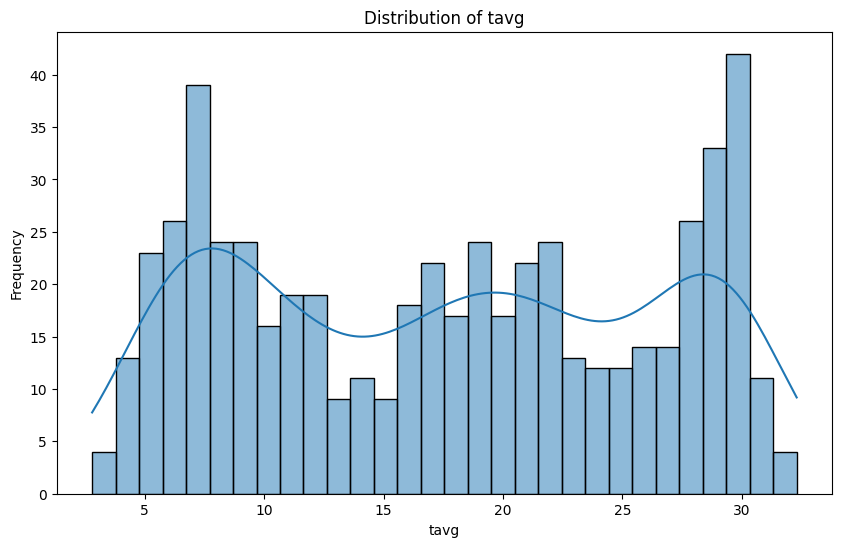

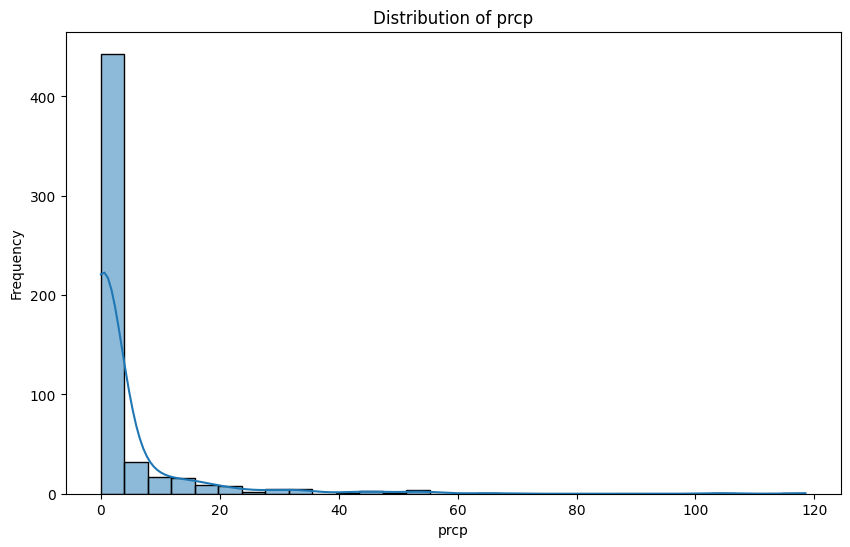

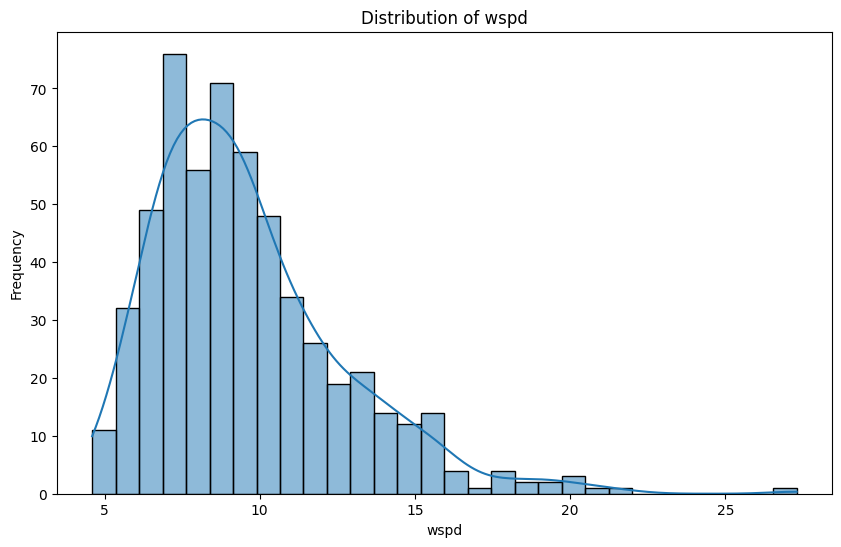

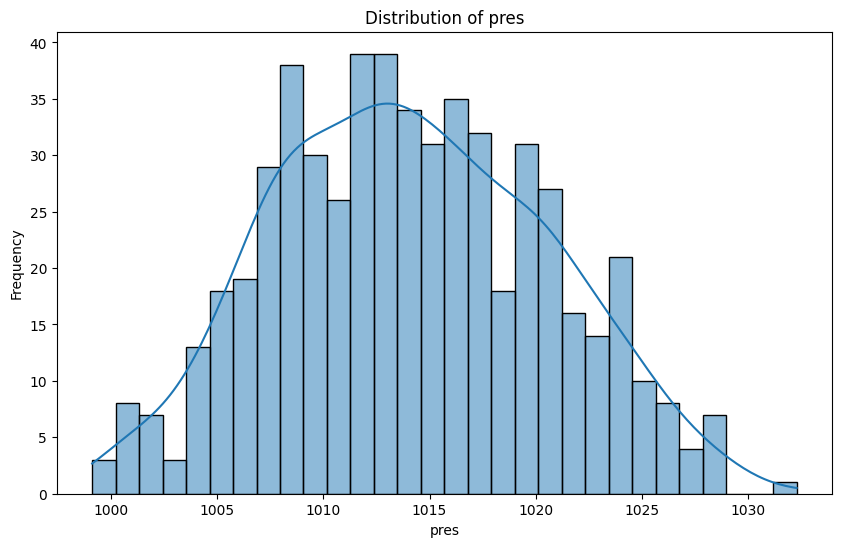

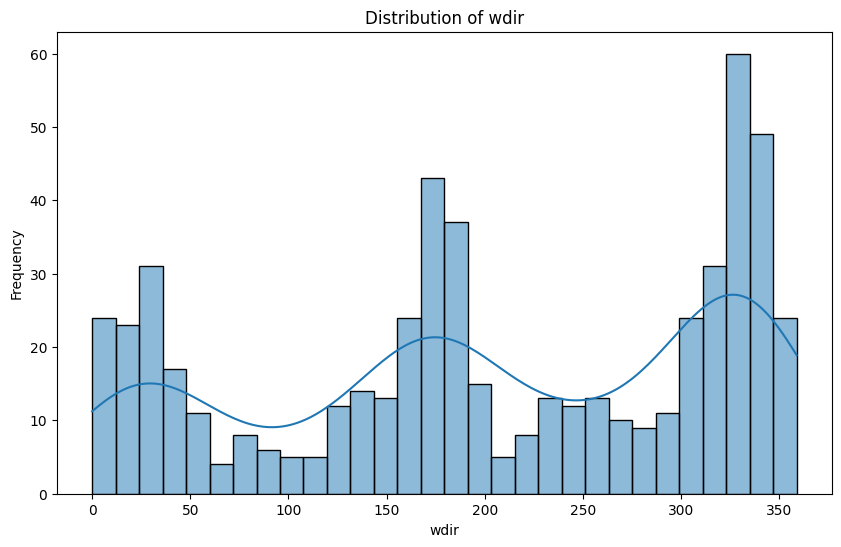

In [7]:
# Vẽ biểu đồ phân phối giá trị
plot_distribution(dataset, 'tavg')
plot_distribution(dataset, 'prcp')
plot_distribution(dataset, 'wspd')
plot_distribution(dataset, 'pres')
plot_distribution(dataset, 'wdir')

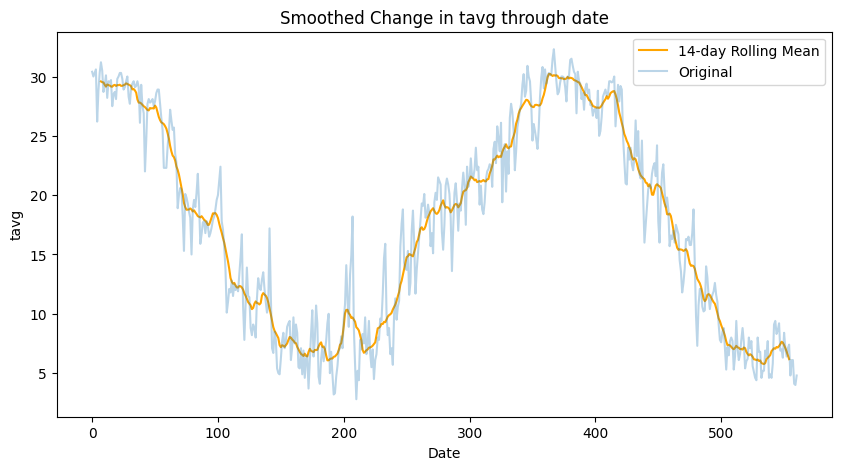

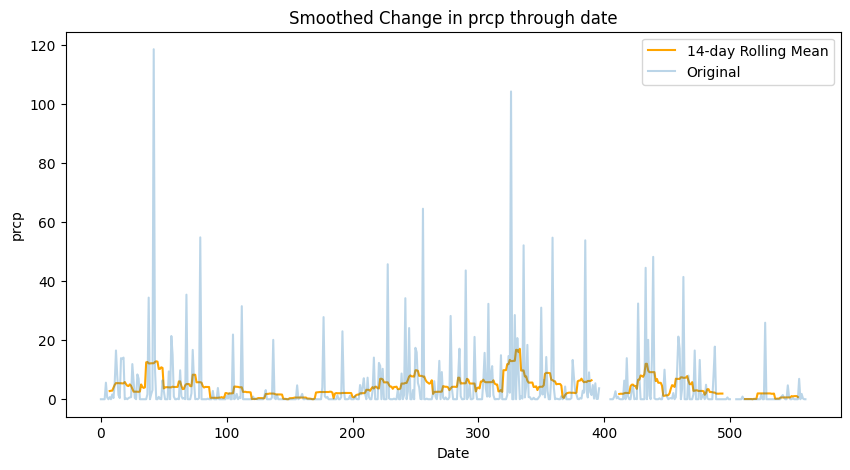

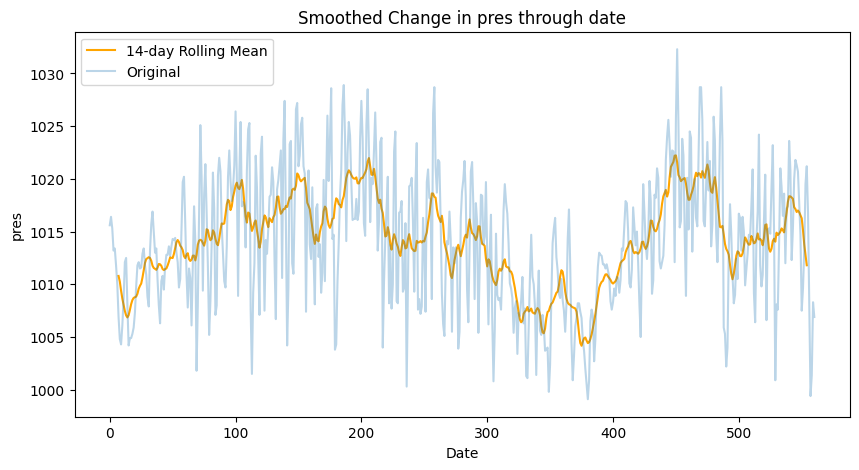

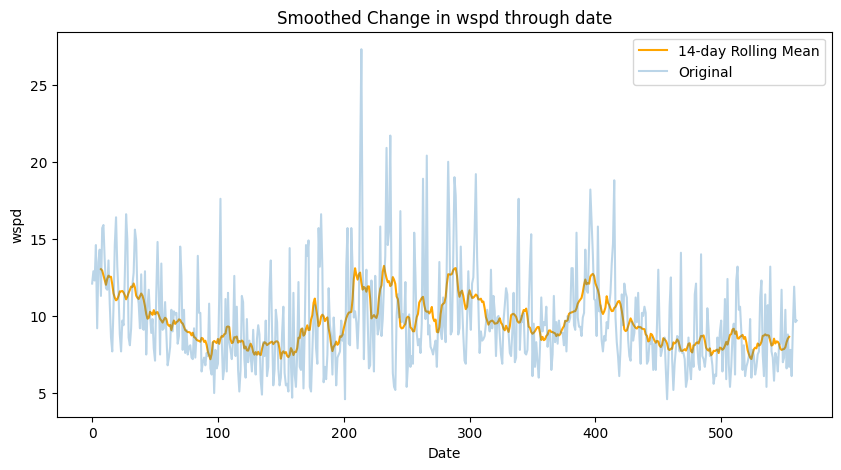

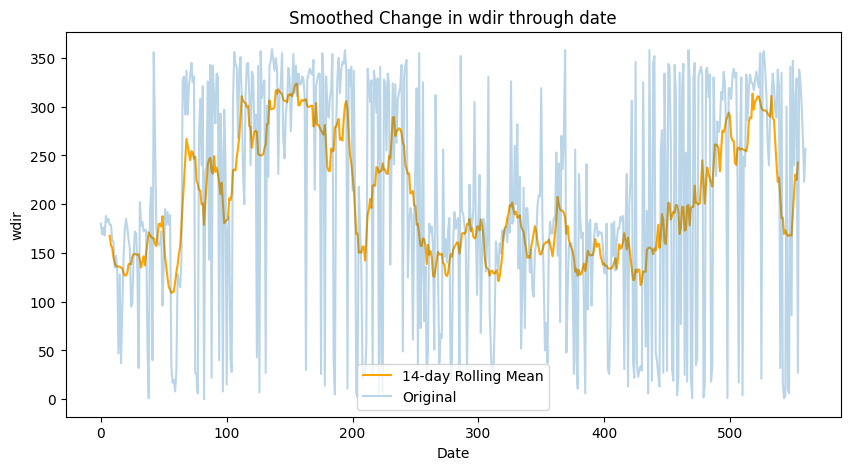

In [8]:
# Vẽ biểu đồ sự thay đổi, biến thiên
plot_smoothed_time_series(dataset, column="tavg", window=14)
plot_smoothed_time_series(dataset, column="prcp", window=14)
plot_smoothed_time_series(dataset, column="pres", window=14)
plot_smoothed_time_series(dataset, column="wspd", window=14)
plot_smoothed_time_series(dataset, column="wdir", window=14)


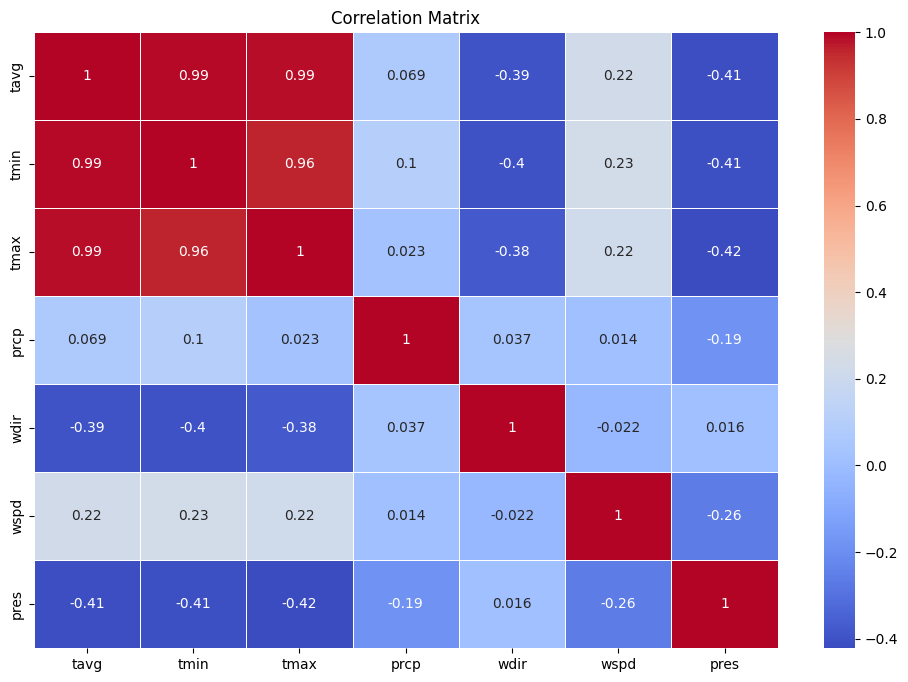

In [9]:
# Ma trận tương quan
numeric_data = dataset.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Step 2: Preprocess data

In [10]:
# Preprocess data
dataset = preprocess_data(dataset)

## Step 3: Augment data

In [11]:
# Augment data with gaussian
stddev = 0.05
mean = 0.0
dataset_aug_gaus = augment_with_gaussian(dataset, mean, stddev)

In [12]:
# Augment data with numpy
dataset_aug_numpy = augment_timeseries_data(dataset, len(dataset))

Kích thước dữ liệu gốc: (561, 7)
Kích thước dữ liệu tăng cường: (1122, 7)
                 tavg       tmin       tmax      prcp        wdir       wspd  \
2022-01-13  30.480854  26.983194  35.123256 -0.000462  180.060597  12.090165   
2022-01-14  29.945433  26.161852  35.520160 -0.029684  168.942600  12.836124   
2022-01-15  30.261305  25.911026  35.892870  0.002966  175.908861  12.283094   
2022-01-16  30.565403  27.689038  35.346174 -0.060788  167.931359  14.521389   
2022-01-17  26.239185  22.645383  32.753210  5.610929  188.007466   9.244385   
...               ...        ...        ...       ...         ...        ...   
2025-02-03   6.100000   4.200000   9.000000  0.000000  326.000000   6.100000   
2025-02-04   6.100000   3.100000  10.100000  1.800000  302.000000   9.300000   
2025-02-05   4.100000   0.600000   7.900000  0.300000  267.000000  11.900000   
2025-02-06   4.000000  -0.300000   8.700000  0.000000  223.000000   9.600000   
2025-02-07   4.800000   0.000000  10.200000  0

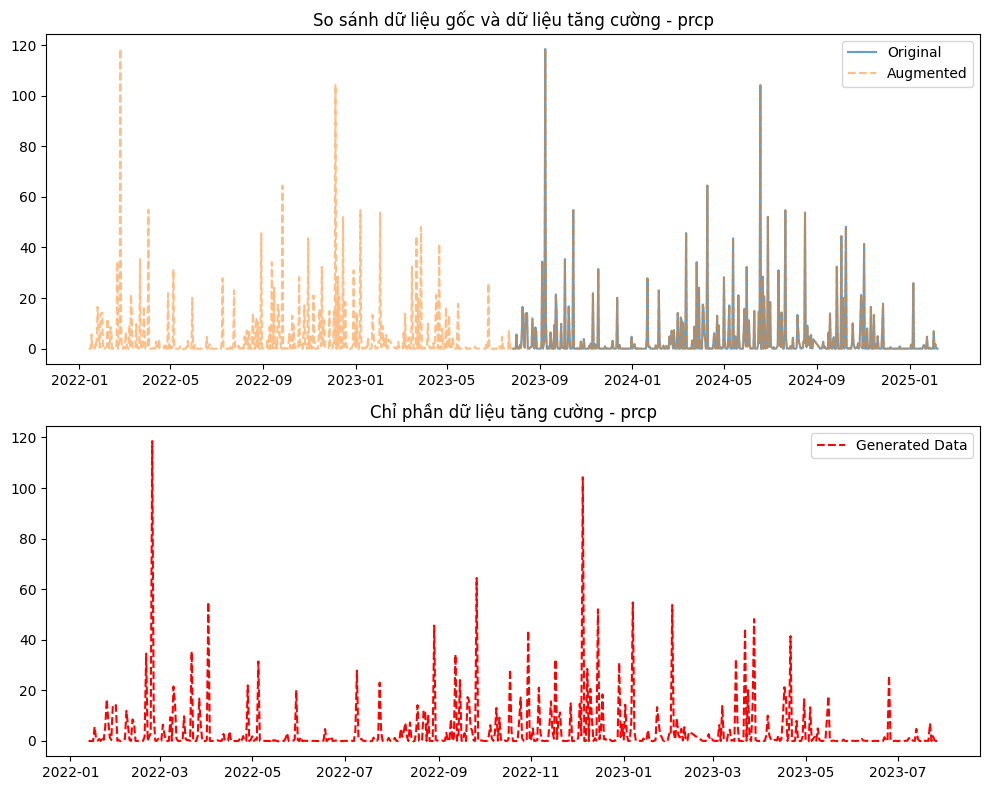

In [13]:
# Kiểm tra dữ liệu sau tăng cường
print("Kích thước dữ liệu gốc:", dataset.shape)
print("Kích thước dữ liệu tăng cường:", dataset_aug_gaus.shape)

# In tập dữ liệu tăng cường
print (dataset_aug_gaus)
# Gọi hàm để so sánh dữ liệu của cột 'tavg'
compare_original_augmented(dataset, dataset_aug_gaus, 'prcp')

## Step 4: Stationary check and Make data stationary if needed

In [14]:
stationarity_results = check_stationarity(dataset)
print (stationarity_results)

  Column  ADF Statistic   p-value Stationary
0   tavg      -0.944859  0.772841         No
1   tmin      -1.282130  0.637308         No
2   tmax      -1.064603  0.728980         No
3   prcp     -23.561866  0.000000        Yes
4   wdir      -2.653818  0.082376         No
5   wspd      -4.996294  0.000023        Yes
6   pres      -3.525647  0.007352        Yes


In [15]:
dataset = make_stationary(dataset)
stationarity_results = check_stationarity(dataset)
print (stationarity_results)

  Column  ADF Statistic       p-value Stationary
0   tavg     -10.100431  1.063053e-17        Yes
1   tmin     -13.014111  2.531978e-24        Yes
2   tmax     -11.497219  4.583005e-21        Yes
3   prcp     -11.682156  1.731008e-21        Yes
4   wdir      -9.523666  3.017700e-16        Yes
5   wspd      -9.859763  4.263951e-17        Yes
6   pres     -12.063681  2.436365e-22        Yes


            tavg  tmin  tmax  prcp  wdir  wspd  pres
date                                                
2023-07-29  -0.4  -0.8   0.4   0.0 -11.0   0.8   0.8
2023-07-30   0.3  -0.3   0.4   0.0   7.0  -0.6  -1.1
2023-07-31   0.3   1.8  -0.6   0.0  -8.0   2.3  -2.1
2023-08-01  -4.4  -5.1  -2.6   5.6  20.0  -5.4   0.2
2023-08-02   2.6   1.6   1.6  -5.0  -6.0   4.3  -1.6
...          ...   ...   ...   ...   ...   ...   ...
2025-02-03   1.3   1.0   0.2  -6.9 -12.0  -1.7  -8.5
2025-02-04   0.0  -1.1   1.1   1.8 -24.0   3.2  -8.9
2025-02-05  -2.0  -2.5  -2.2  -1.5 -35.0   2.6   2.0
2025-02-06  -0.1  -0.9   0.8  -0.3 -44.0  -2.3   6.9
2025-02-07   0.8   0.3   1.5   0.0  34.0   0.1  -1.4

[560 rows x 7 columns]
(560, 7)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 560 entries, 2023-07-29 to 2025-02-07
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tavg    560 non-null    float64
 1   tmin    560 non-null    float64
 2   tm

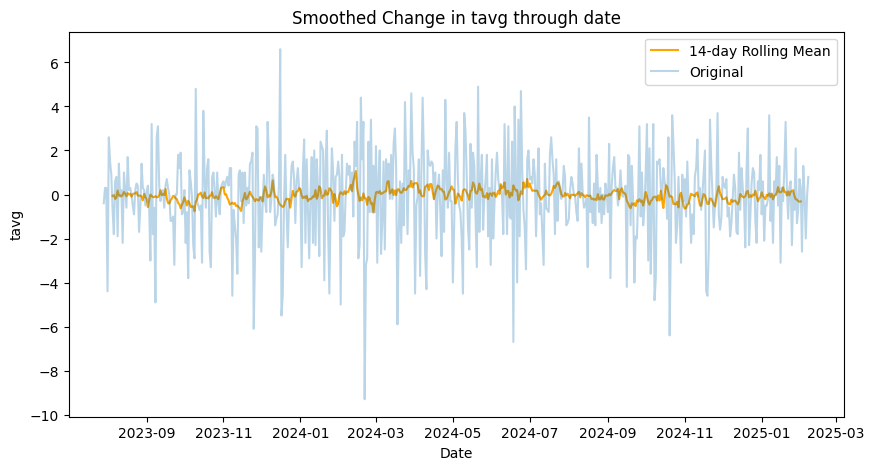

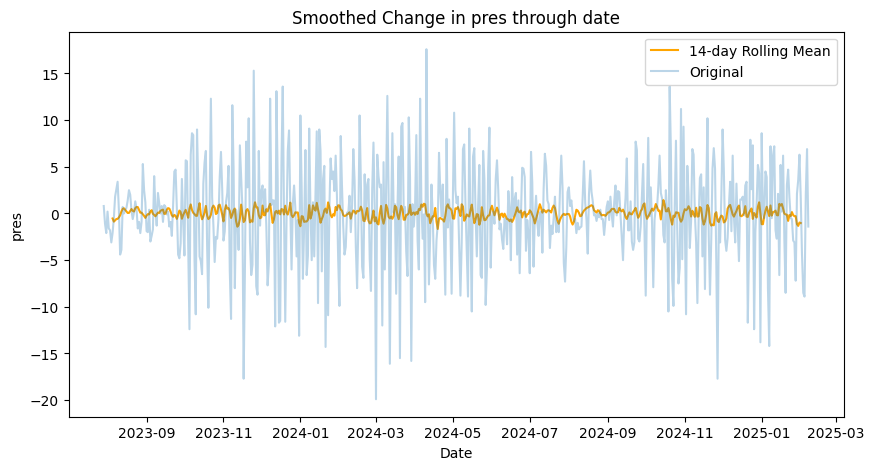

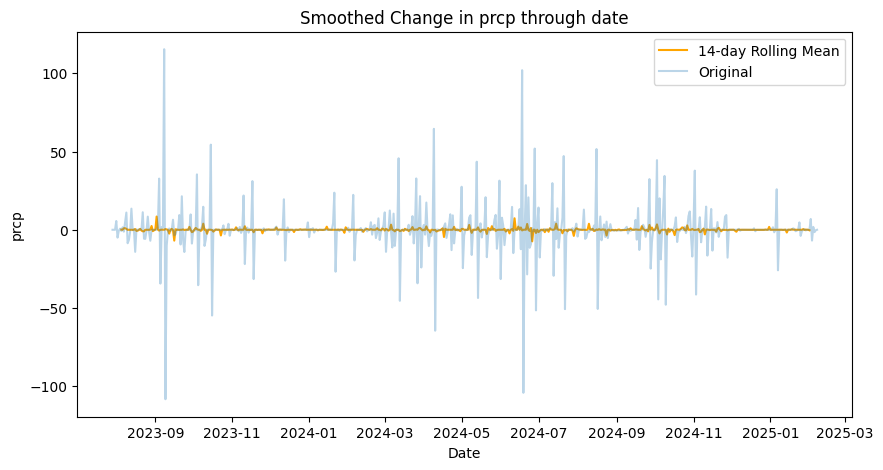

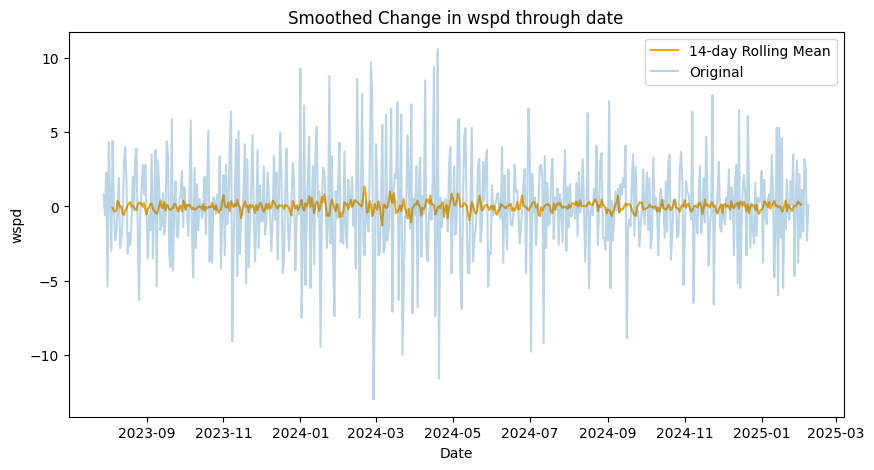

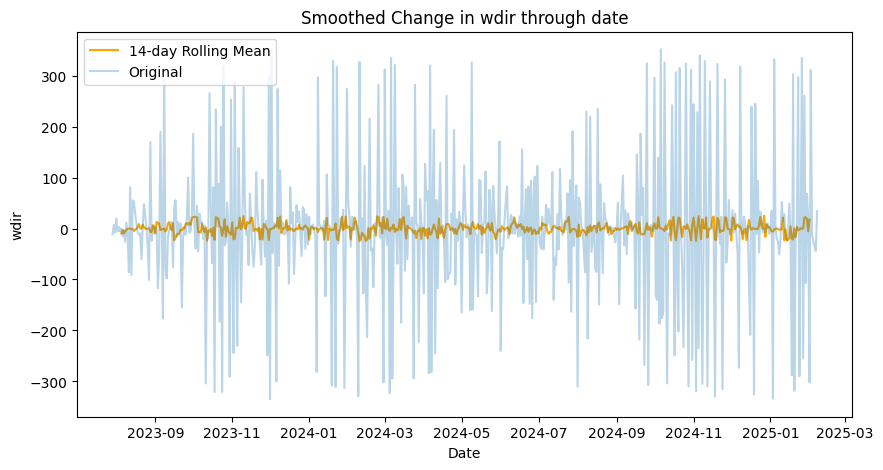

In [16]:
# Xem lại dữ liệu sau khi dừng hoá
print (dataset)
check_information_dataset (dataset)
plot_smoothed_time_series(dataset, column="tavg", window=14)
plot_smoothed_time_series(dataset, column="pres", window=14)
plot_smoothed_time_series(dataset, column="prcp", window=14)
plot_smoothed_time_series(dataset, column="wspd", window=14)
plot_smoothed_time_series(dataset, column="wdir", window=14)

## Step 5: Normalization

In [17]:
# Chuẩn hoá min-max
min_val = 0
max_val = 1
dataset,scaler = min_max_normalize (min_val,max_val,dataset)

In [18]:
# Chuẩn hoá z-socre
dataset,scaler = z_score_normalize (dataset)

                tavg      tmin      tmax          prcp      wdir      wspd  \
date                                                                         
2023-07-29 -0.180369 -0.385367  0.144517 -8.107725e-16 -0.080970  0.245500   
2023-07-30  0.176005 -0.129066  0.144517 -8.107725e-16  0.049891 -0.181836   
2023-07-31  0.176005  0.947398 -0.180632 -8.107725e-16 -0.059160  0.703360   
2023-08-01 -2.216791 -2.589554 -0.830929  3.656292e-01  0.144402 -1.646987   
2023-08-02  1.346948  0.844877  0.534696 -3.264546e-01 -0.044620  1.313840   
...              ...       ...       ...           ...       ...       ...   
2025-02-03  0.685111  0.537316  0.079487 -4.505074e-01 -0.088240 -0.517600   
2025-02-04  0.023273 -0.539147  0.372121  1.175237e-01 -0.175481  0.978076   
2025-02-05 -0.994938 -1.256790 -0.700870 -9.793638e-02 -0.255452  0.794932   
2025-02-06 -0.027637 -0.436627  0.274577 -1.958728e-02 -0.320883 -0.700744   
2025-02-07  0.430558  0.178495  0.502181 -8.107725e-16  0.246183

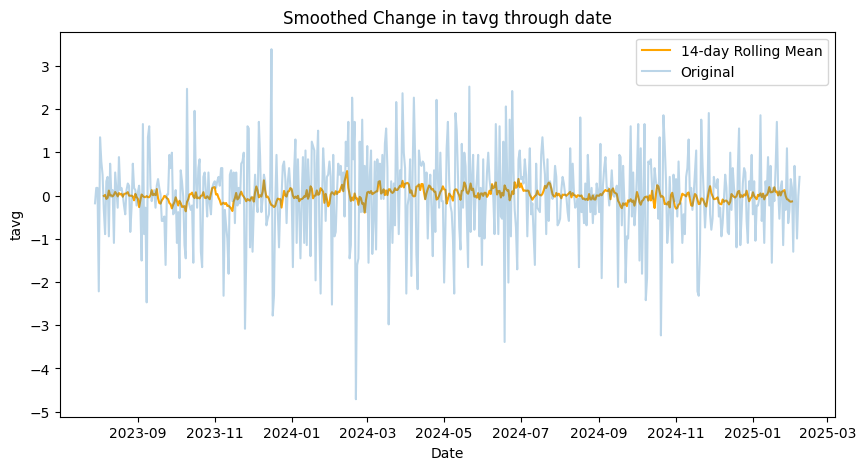

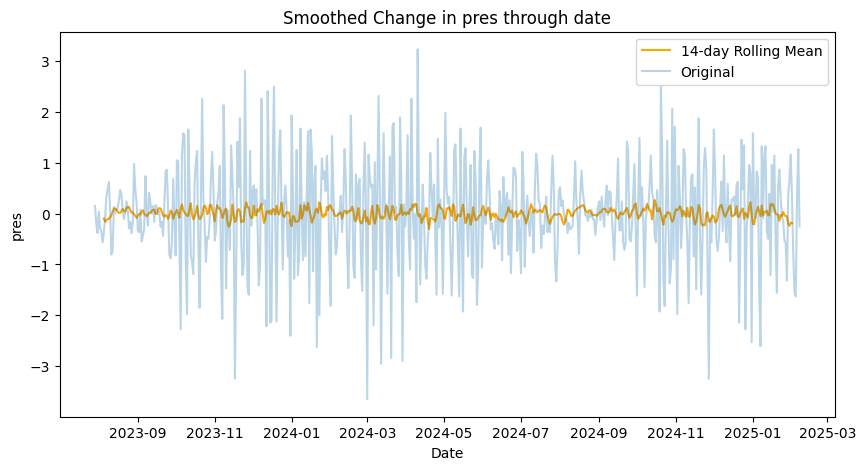

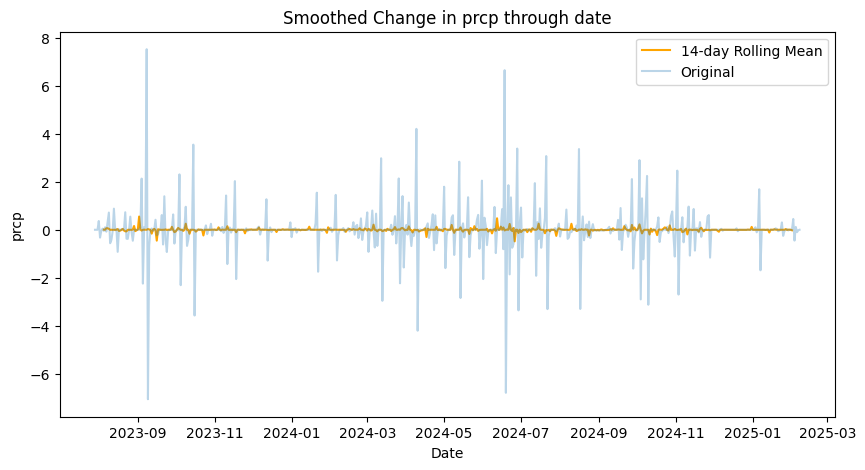

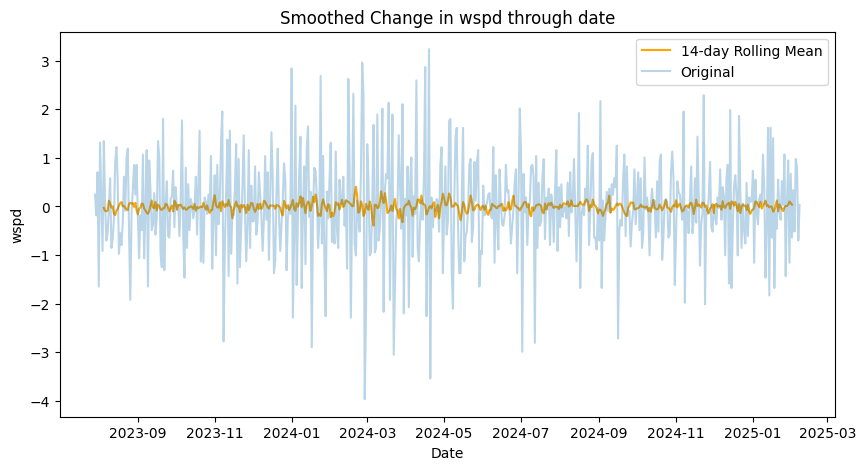

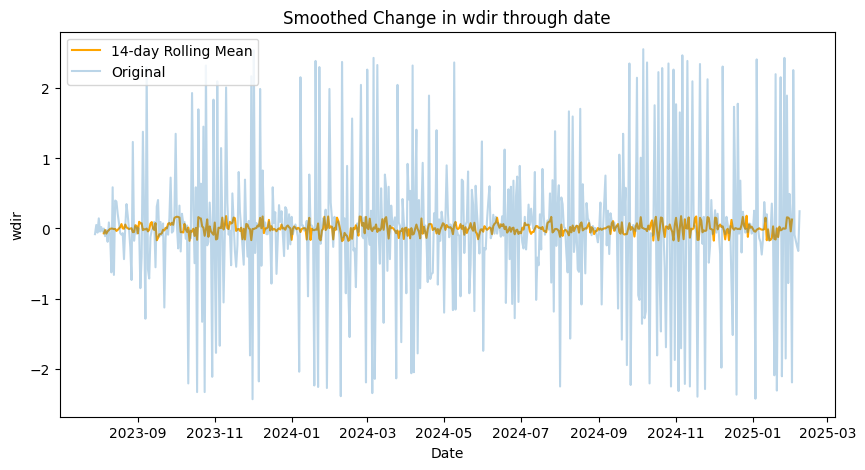

In [19]:
# Kiểm tra dữ liệu sau chuẩn hoá
print(dataset)
plot_smoothed_time_series(dataset, column="tavg", window=14)
plot_smoothed_time_series(dataset, column="pres", window=14)
plot_smoothed_time_series(dataset, column="prcp", window=14)
plot_smoothed_time_series(dataset, column="wspd", window=14)
plot_smoothed_time_series(dataset, column="wdir", window=14)

## Step 6: Train Test Val Split

In [20]:
dataset.drop(['tmin', 'tmax'], axis=1, inplace=True)
train_size = int(len(dataset) * 0.8)
train, test = dataset[:train_size], dataset[train_size:]
val_size = int(len(train) * 0.2)
train_final, val = train[:-val_size], train[-val_size:]

(359, 5)
(89, 5)
(112, 5)


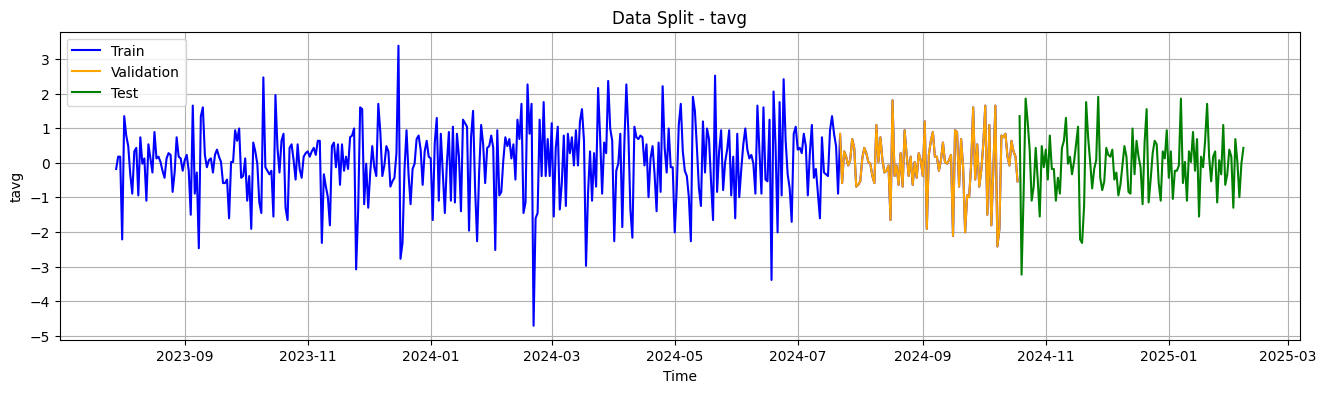

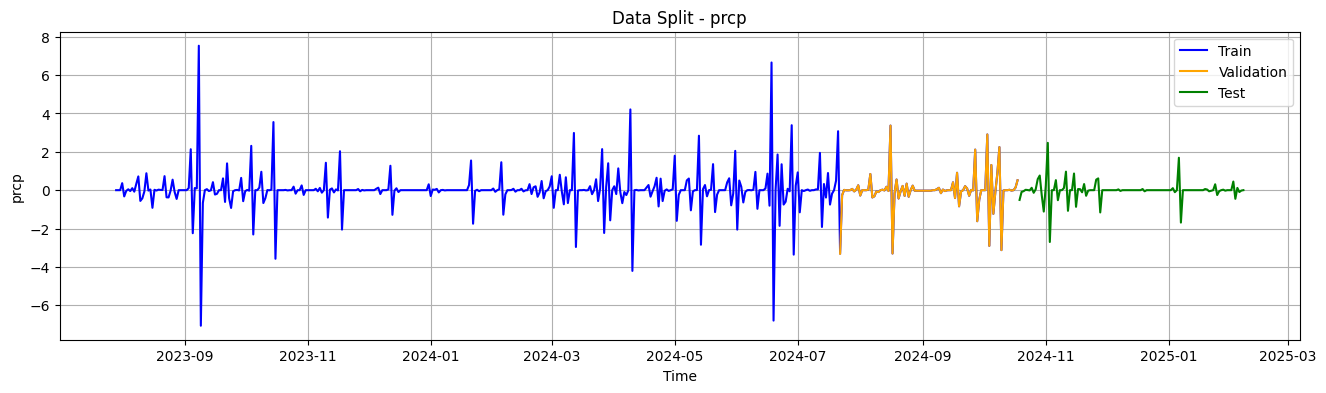

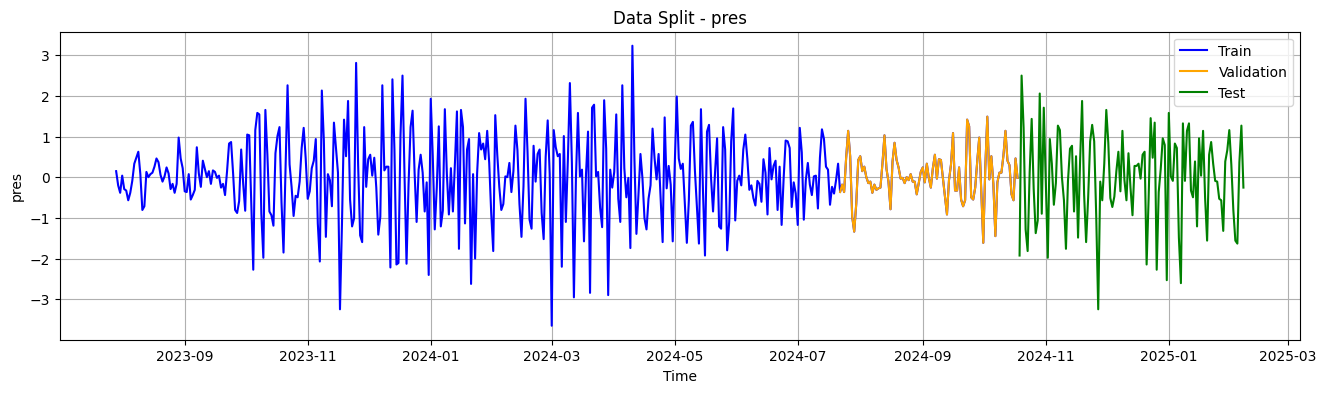

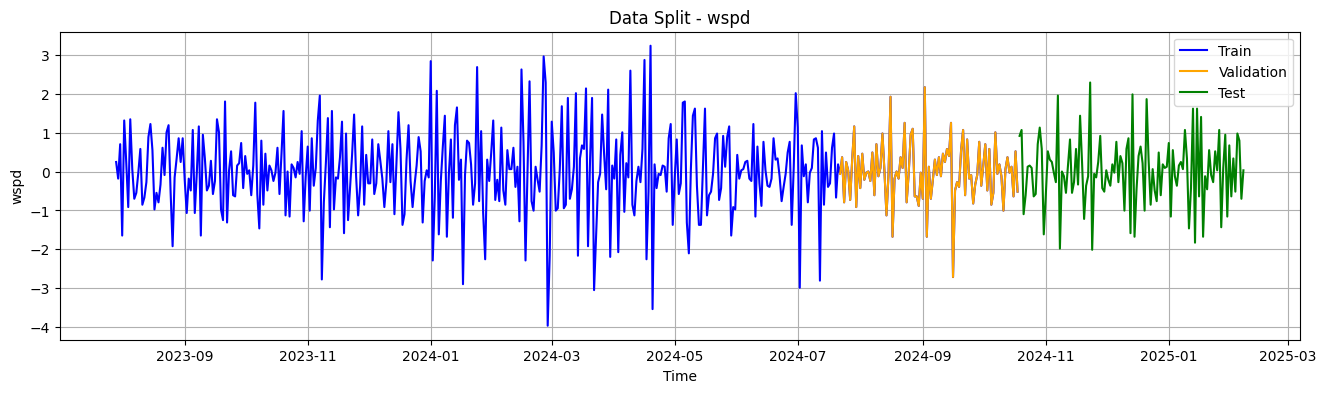

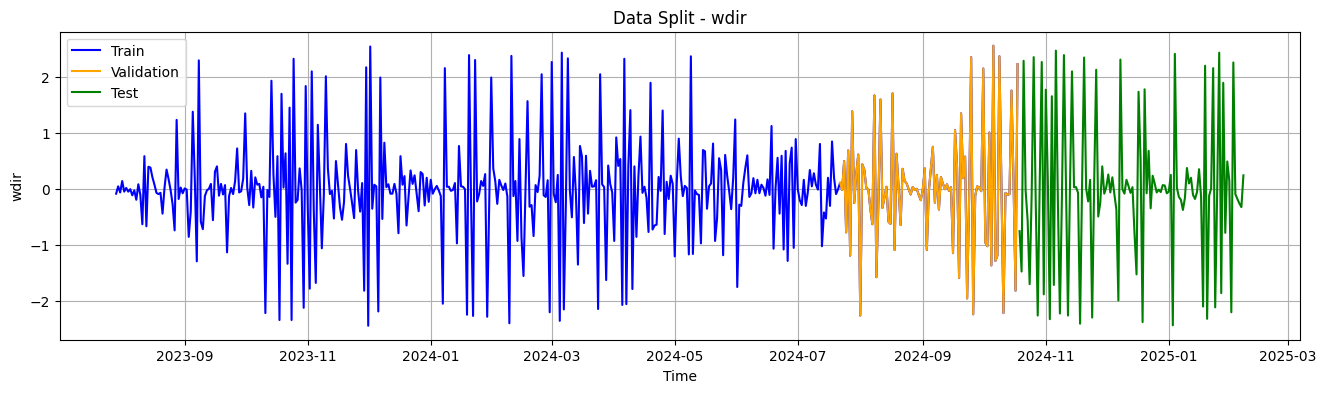

In [21]:
# Kiểm tra tập train-val-test
print (train_final.shape)
print (val.shape)
print (test.shape)
plot_dataset_split('tavg')
plot_dataset_split('prcp')
plot_dataset_split('pres')
plot_dataset_split('wspd')
plot_dataset_split('wdir')

 ## Step 7: Train Model

100%|██████████| 31/31 [00:00<00:00, 36.39it/s] 


     p       AIC
0    0 -0.388111
1    1 -1.109716
2    2 -1.579405
3    3 -1.753913
4    4 -1.890290
5    5 -1.912201
6    6 -1.882275
7    7 -1.887814
8    8 -1.831018
9    9 -1.834441
10  10 -1.802775
11  11 -1.795743
12  12 -1.755148
13  13 -1.730899
14  14 -1.693068
15  15 -1.625147
16  16 -1.598742
17  17 -1.640221
18  18 -1.603403
19  19 -1.596670
20  20 -1.555555
21  21 -1.475117
22  22 -1.436472
23  23 -1.408007
24  24 -1.388561
25  25 -1.339135
26  26 -1.275364
27  27 -1.265930
28  28 -1.244258
29  29 -1.257812
30  30 -1.207314


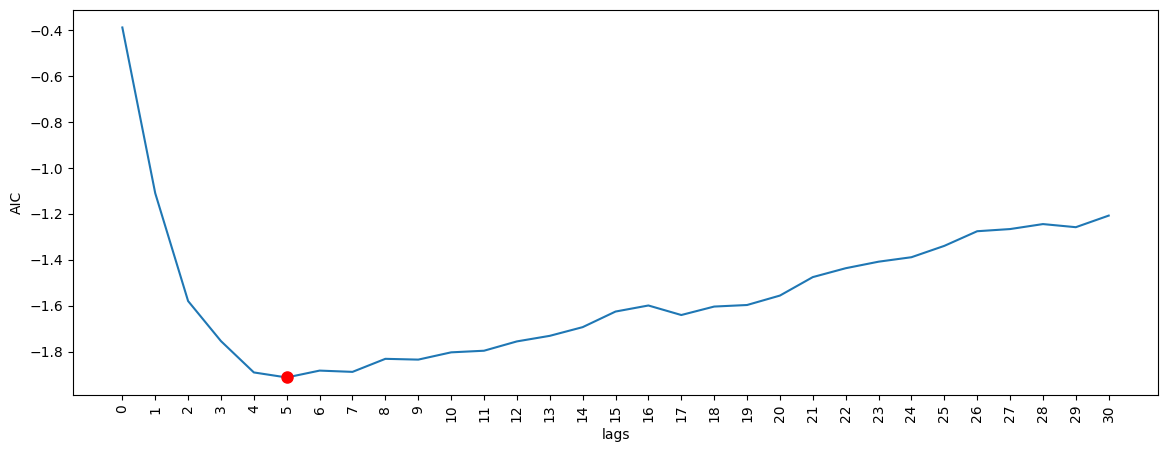

In [22]:
best_lag = find_bestlag (train,31)

In [23]:
import pickle

### FIT FINAL VAR WITH LAG CORRESPONTING TO THE BEST AIC ###
var = VAR(endog=train.values)
var_result = var.fit(maxlags=best_lag)
var_result.aic

with open(f"results/{file_name}/var_result.pkl", "wb") as f:
    pickle.dump(var_result, f)

In [24]:
train_var_pred = create_var_predictions(
                    train_final, var_result, var_result.k_ar, dataset.columns
                )
val_var_pred = create_var_predictions(
                    val, var_result, var_result.k_ar, dataset.columns
                )

In [25]:
# Chuyển đổi dữ liệu
look_back = best_lag
look_ahead = 1

X_train = create_windows(train_var_pred, window_shape=look_back, end_id=-look_ahead)
y_train = create_windows(train_final.values[var_result.k_ar :], window_shape=look_ahead, start_id=look_back)

X_val = create_windows(val_var_pred, window_shape=look_back, end_id=-look_ahead)
y_val = create_windows(val.values[var_result.k_ar :], window_shape=look_ahead, start_id=look_back)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


# Tìm tham số tối ưu
param_grid = {
                    "learning_rate": [7e-4, 1e-3, 3e-3],
                    "batch_size": [64, 256, 512],
                    "units_lstm": [128, 96, 64],  # số nơ ron mạng LSTM
                    "epoch": [70, 120, 160],
                }

best_params, best_mse, search_time = grid_search(
    X_train,
    y_train,
    X_val,
    y_val,
    param_grid,
    look_back,
    look_ahead
)

print("Parameter optimization completed.")
print("**Best Parameters:**")
print(best_params)
print(f"**Best MSE:** {best_mse:.4f}")
print(f"**Search Time:** {search_time:.2f} seconds")
print(f"**Best Lags (VAR):** {var_result.k_ar}")

# Lưu tham số tối ưu vừa tìm được vào file json
grid_search_results = {
                    "best_parameters": best_params,
                    "best_mse": best_mse,
                    "search_time": search_time,
                    "best_lag": best_lag,
                    "look_back": look_back,
                    "look_ahead": look_ahead
                }

with open(
        f"results/{file_name}/DeepVAR_grid_search_results.json",  # noqa: E501
        "w",
    ) as f:
        json.dump(grid_search_results, f)

(349, 5, 5) (349, 1, 5)
(79, 5, 5) (79, 1, 5)
3/3 [==============================] - 1s 6ms/step
Parameter optimization completed.
**Best Parameters:**
{'learning_rate': 0.003, 'batch_size': 256, 'units_lstm': 128, 'epoch': 70}
**Best MSE:** 0.7058
**Search Time:** 1299.77 seconds
**Best Lags (VAR):** 5


In [26]:
# Training
final_model = build_deepvar(
                    input_dim = X_train.shape[2],
                    output_dim = y_train.shape[2],
                    look_back = look_back,
                    look_ahead = look_ahead,
                    lr = best_params["learning_rate"],
                    units_lstm = best_params["units_lstm"]
                )

start_time = time.time()
es = tf.keras.callbacks.EarlyStopping(patience=10, verbose=0, min_delta=0.001, monitor='val_loss', mode='auto', restore_best_weights=True)

try:
    history = final_model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
            epochs=best_params["epoch"],
            batch_size=best_params["batch_size"],
            verbose=1)
    end_time = time.time()

    train_time = end_time - start_time
    print(f"Thời gian huấn luyện: {train_time:.2f} giây")

    with open(
            f"results/{file_name}/training_history.pkl", "wb"
        ) as f:
            pickle.dump(history.history, f)

    final_model.save(
                    f"models/{file_name}/DeepVAR_final_model.keras"
                )
except Exception as e:
    print(f"Training stopped or failed: {e}")
    print("Training completed and model saved.")
    
# Tạo DataFrame chứa loss theo từng epoch
loss_df = pd.DataFrame(
    {
        "Epoch": range(
            1, len(history.history["loss"]) + 1
            ),  # noqa: E501
            "Training Loss": history.history["loss"],
            "Validation Loss": history.history["val_loss"],
            }
            )

Epoch 1/70
2/2 [==============================] - 6s 952ms/step - loss: 1.1223 - mae: 0.7087 - val_loss: 0.7163 - val_mae: 0.5472
Epoch 2/70
2/2 [==============================] - 0s 92ms/step - loss: 1.1178 - mae: 0.7068 - val_loss: 0.7151 - val_mae: 0.5468
Epoch 3/70
2/2 [==============================] - 0s 92ms/step - loss: 1.1136 - mae: 0.7056 - val_loss: 0.7144 - val_mae: 0.5464
Epoch 4/70
2/2 [==============================] - 0s 86ms/step - loss: 1.1092 - mae: 0.7043 - val_loss: 0.7139 - val_mae: 0.5463
Epoch 5/70
2/2 [==============================] - 0s 91ms/step - loss: 1.1042 - mae: 0.7033 - val_loss: 0.7138 - val_mae: 0.5464
Epoch 6/70
2/2 [==============================] - 0s 89ms/step - loss: 1.0975 - mae: 0.7021 - val_loss: 0.7143 - val_mae: 0.5469
Epoch 7/70
2/2 [==============================] - 0s 92ms/step - loss: 1.0907 - mae: 0.7013 - val_loss: 0.7161 - val_mae: 0.5483
Epoch 8/70
2/2 [==============================] - 0s 87ms/step - loss: 1.0821 - mae: 0.7005 - va

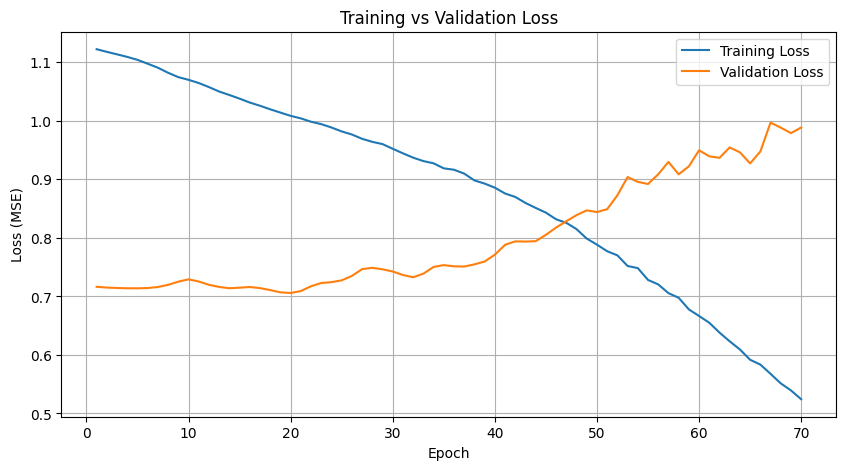

In [27]:
# Vẽ biểu đồ loss
plot_loss_curve(loss_df)

## Step 8: Test Model

In [28]:
start_time = time.time()
deepvar_model = load_model(f"models/{file_name}/DeepVAR_final_model.keras")
test_var_pred = create_var_predictions( test, var_result, best_lag, test.columns)
X_test = create_windows(test_var_pred, window_shape=look_back, end_id=-look_ahead)
y_test = create_windows(test.values[var_result.k_ar :], window_shape=look_ahead, start_id=look_back)
predictions = deepvar_model.predict(X_test)
execution_time = time.time() - start_time

4/4 [==============================] - 1s 6ms/step


In [29]:
evaluation_df = evaluate_multivariate_forecast(y_test, predictions, dataset.columns)
evaluation_df_overall = evaluate_overall_forecast(y_test, predictions, execution_time)
print (evaluation_df)
print (evaluation_df_overall)

     Variable       MSE      RMSE       MAE      CV_RMSE
tavg     tavg  1.255199  1.120357  0.893875   -24.040006
prcp     prcp  0.568029  0.753677  0.528657  -123.939303
wdir     wdir  1.962266  1.400809  1.062955    82.240952
wspd     wspd  1.335809  1.155772  0.944606   119.307927
pres     pres  2.022415  1.422116  1.125406 -1900.101163
                Metric      Value
0  Test Time (seconds)       2.39
1             Test MSE     1.4287
2             Test MAE     0.9111
3            Test RMSE     1.1953
4         Test CV RMSE  -223.7301


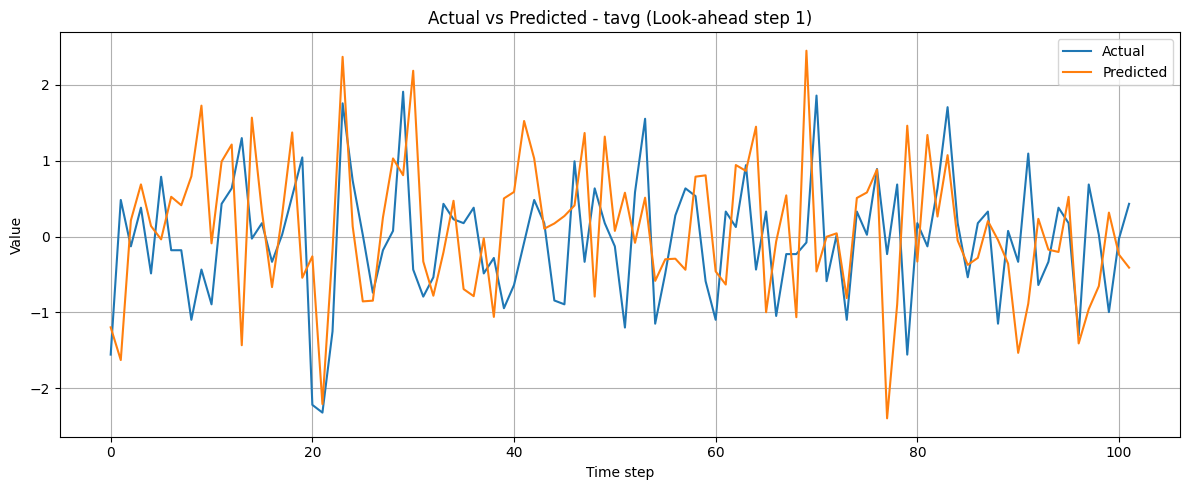

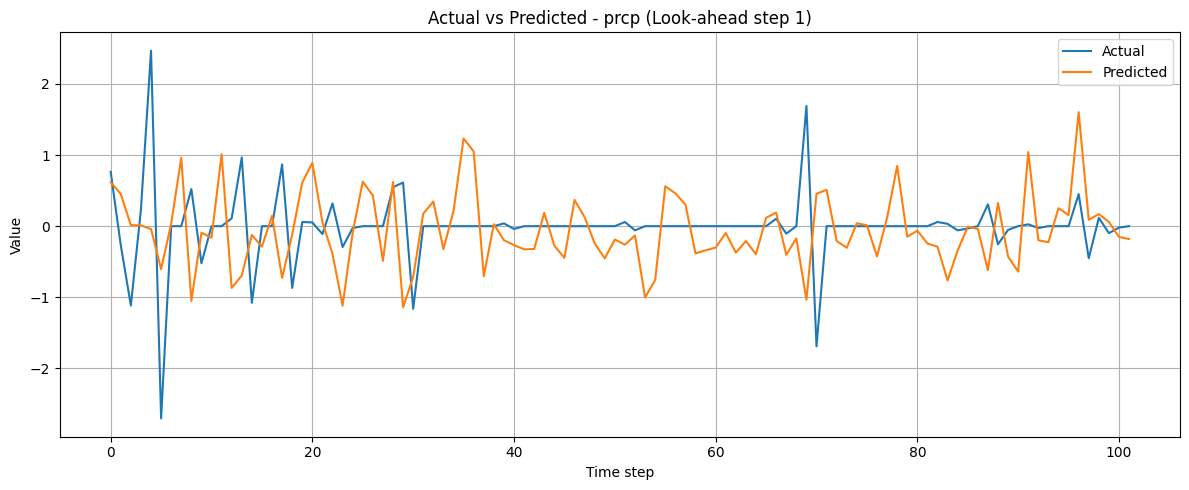

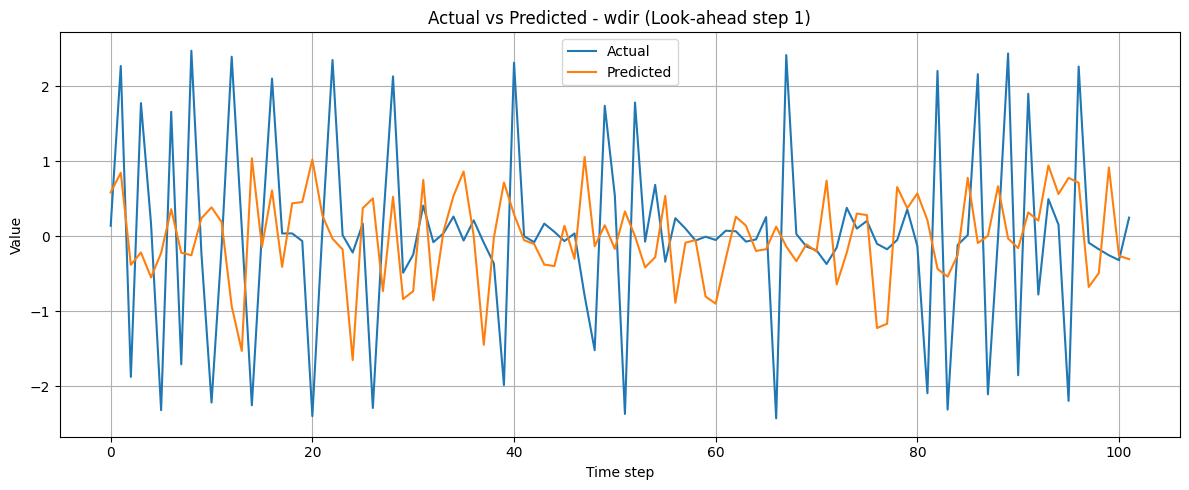

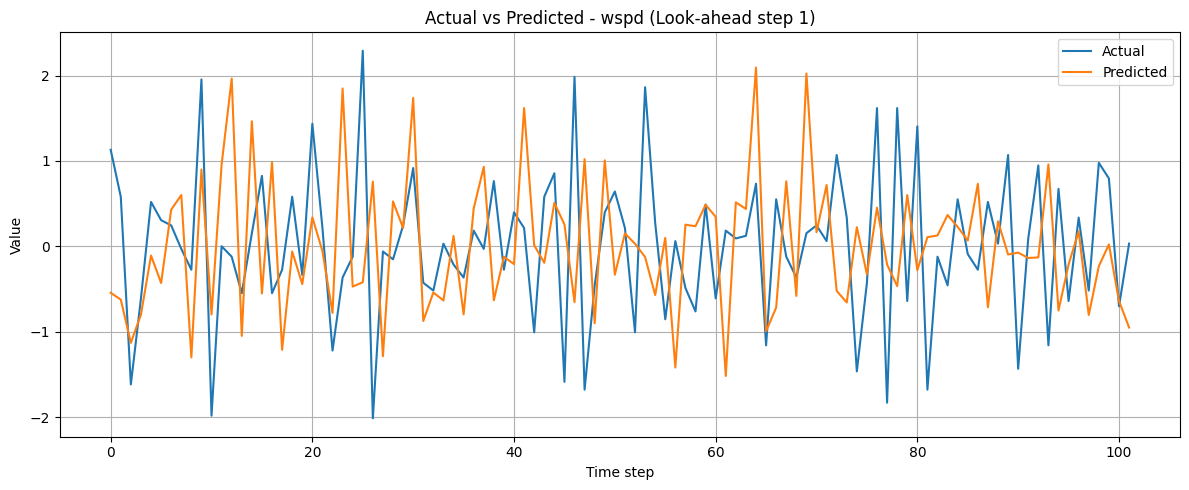

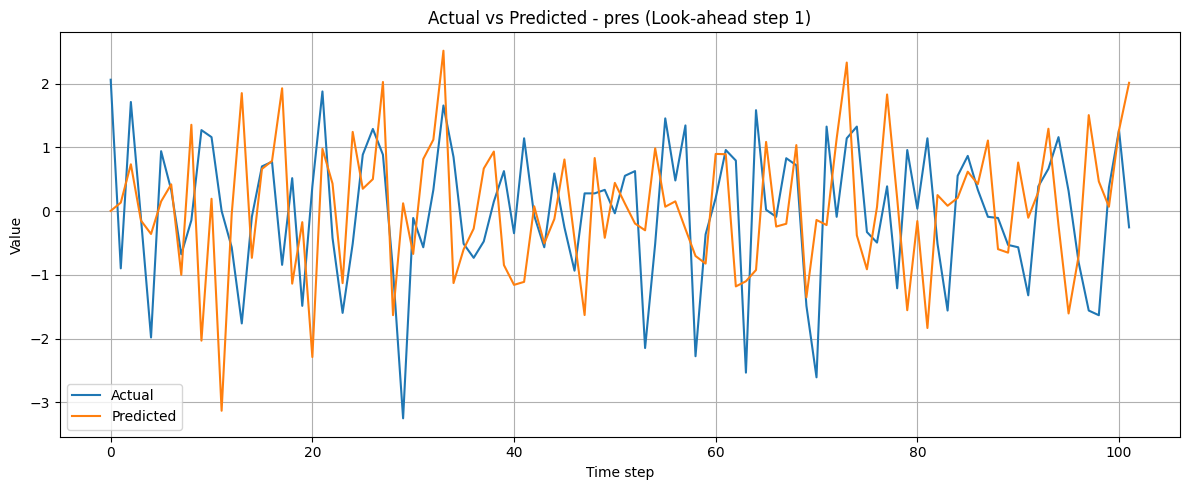

In [30]:
plot_actual_vs_predicted(y_test, predictions, variable_index=0, step_index=0, variable_name='tavg')
plot_actual_vs_predicted(y_test, predictions, variable_index=1, step_index=0, variable_name='prcp')
plot_actual_vs_predicted(y_test, predictions, variable_index=2, step_index=0, variable_name='wdir')
plot_actual_vs_predicted(y_test, predictions, variable_index=3, step_index=0, variable_name='wspd')
plot_actual_vs_predicted(y_test, predictions, variable_index=4, step_index=0, variable_name='pres')

## Step 9: Predict Future Values

In [31]:
# Bước 1: Load dữ liệu thời tiết khoảng 1 tháng gần đây từ file .csv
weather_recent = pd.read_csv("Data/export.csv")
weather_recent.drop(['tmin','tmax','snow','wpgt','tsun'], axis=1, inplace=True)
weather_recent = preprocess_data(weather_recent)
print(weather_recent)

            tavg  prcp  wdir  wspd    pres
date                                      
2025-01-01  27.2   0.0     5   7.5  1009.3
2025-01-02  27.5   0.5   325   7.6  1009.4
2025-01-03  28.5   3.0    31   9.5  1009.6
2025-01-04  27.6   0.0     7   8.2  1009.8
2025-01-05  27.4   0.0   337   9.0  1010.8
2025-01-06  27.0   0.0   274   7.7  1010.5
2025-01-07  26.8   0.0   203   9.5  1010.8
2025-01-08  27.0   0.0    26   7.3  1010.8
2025-01-09  26.8   0.0   303   7.6  1011.6
2025-01-10  27.9   0.0    58   8.0  1012.8
2025-01-11  26.6   0.0    16  11.7  1013.6
2025-01-12  26.0   0.0    25  12.7  1013.0
2025-01-13  24.7   0.0   304  10.9  1012.0
2025-01-14  25.4   9.0     0   7.1  1011.8
2025-01-15  27.9   1.0    14   7.3  1011.3
2025-01-16  28.3   0.0    44  12.5  1011.7
2025-01-17  26.8   0.0    67  10.4  1011.0
2025-01-18  26.8   0.0   356   7.4  1010.3
2025-01-19  27.5   0.0   257   8.1  1009.4
2025-01-20  27.1   0.0   117   8.9  1009.2
2025-01-21  26.5   0.0    63   8.3  1010.0
2025-01-22 

In [32]:
# Bước 2: Chuẩn hoá dữ liệu
weather_recent_scaled,scaler = min_max_normalize (min_val,max_val,weather_recent)

In [33]:
# Bước 3: Đưa dữ liệu vào mô hình
deepvar_model = load_model(f"models/{file_name}/DeepVAR_final_model.keras")
var_pred = create_var_predictions( weather_recent_scaled, var_result, best_lag, weather_recent_scaled.columns)
var_pred_input = create_windows(var_pred, window_shape=look_back, end_id=-look_ahead)
predictions = deepvar_model.predict(var_pred_input) 



1/1 [==============================] - 1s 1s/step


In [34]:
predictions = scaler.inverse_transform (predictions.reshape(-1, predictions.shape[-1])).reshape(predictions.shape)
# predictions shape: (1, n_days, num_features)
n_days = predictions.shape[1]

# Tạo các ngày tiếp theo dựa trên ngày cuối cùng của dữ liệu
last_date = weather_recent.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days, freq='D')

# predictions[0]: lấy ra chuỗi (n_days, num_features)
predicted_df = pd.DataFrame(predictions[0], columns=weather_recent.columns, index=future_dates)
predicted_df.index.name = "Date"

# In kết quả
print("📅 Dự báo thời tiết cho ngày tiếp theo:")
print(predicted_df)


📅 Dự báo thời tiết cho ngày tiếp theo:
                 tavg      prcp       wdir      wspd         pres
Date                                                             
2025-02-01  25.711241 -8.289712  51.459641  8.651926  1003.670044


In [35]:
print(predictions.shape)

(21, 1, 5)
